# Clustering I (K-Means)

Clustering adalah metode *unsupervised learning* yang bertujuan mengelompokkan data ke dalam beberapa kelompok (cluster) berdasarkan kemiripan karakteristiknya, tanpa menggunakan label target. Ini berbeda dengan *supervised learning*, di mana algoritma belajar dari data yang sudah diberi label jawaban.

Sederhananya, data yang mirip satu sama lain dikelompokkan ke cluster yang sama, sedangkan data yang berbeda karakteristiknya dipisahkan ke cluster lain. Pengukuran kemiripan ini umumnya didasarkan pada perhitungan jarak, seperti jarak Euclidean, Manhattan, atau Cosine similarity.

**K-Means** adalah salah satu algoritma clustering yang paling populer. Algoritma ini mencoba menemukan K titik pusat (*centroid*) yang paling representatif untuk mewakili kelompok-kelompok data di sekitarnya, lalu setiap titik data bergabung ke pusat terdekatnya.

### 1.1 Install Library

In [ ]:
# pip install pandas numpy matplotlib seaborn scikit-learn

### 1.2. Import Library yang Dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, make_moons
from sklearn.metrics import silhouette_score

### 1.3. Mempersiapkan Dataset
Pertemuan ini menggunakan dataset dari scikit-learn, yaitu dataset **Iris**. Dataset ini berisi data panjang dan lebar sepal serta petal dari tiga jenis bunga Iris.
- #### 1.3.1 Import Dataset

In [4]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
display (df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


- #### 1.3.2 Melihat Informasi Dataset

- #### 1.3.3 Menyimpan Label Spesies Asli (untuk validasi nanti)

Label spesies asli TIDAK akan digunakan saat proses clustering berlangsung (karena K-Means bersifat *unsupervised*), tetapi akan dipakai nanti pada tahap Interpretasi Hasil untuk membandingkan hasil cluster dengan kelompok aslinya.

In [5]:
species = data.target
species_names = data.target_names
print(species)
print(species_names)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


### 1.4. Standarisasi Data

K-Means menghitung jarak antar titik data, sehingga semua fitur perlu berada pada skala yang sama sebelum diproses. Gunakan `StandardScaler` dari `sklearn.preprocessing`.

In [6]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
print(df_scaled[:5])    

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


---
## 2. Menentukan Jumlah Cluster dengan Elbow Method

Karena jumlah cluster optimal (K) tidak diketahui di awal, kita perlu mencoba beberapa nilai K dan menghitung nilai **inertia (WCSS — Within-Cluster Sum of Squares)** untuk masing-masing nilai K tersebut.

Semakin kecil nilai WCSS, semakin rapat/dekat titik-titik data dalam suatu cluster dengan centroid-nya. Namun, WCSS akan selalu menurun seiring bertambahnya K — carilah titik di mana penurunan grafiknya mulai melandai tajam (membentuk pola seperti siku tangan), itulah K optimal.

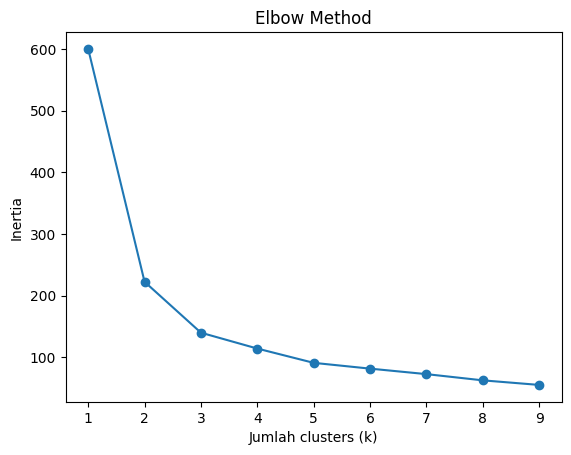

[600.0, 222.36170496502297, 139.82049635974974, 114.09254690403085, 90.92751382392048, 81.54439095511778, 72.63114382667186, 62.5406056957812, 55.11949280529058]


In [8]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Jumlah clusters (k)')
plt.ylabel('Inertia')
plt.title("Elbow Method")
plt.show()

print(inertia)

Dari grafik Elbow di atas, tentukan jumlah cluster optimal yang akan dipakai pada langkah berikutnya.

---
## 3. Implementasi K-Means

Setelah jumlah cluster (K) dipilih berdasarkan Elbow Method, jalankan algoritma K-Means menggunakan `KMeans` dari `sklearn.cluster`.

**Ingat:**
- Gunakan `n_init=10` untuk mengurangi risiko algoritma terjebak pada solusi lokal yang kurang optimal.
- Gunakan `random_state` agar hasil clustering dapat direproduksi ulang secara konsisten.

---
## 4. Visualisasi Hasil Clustering dengan Scatter Plot

Visualisasikan hasil pengelompokan menggunakan `sns.scatterplot()`, dengan warna (`hue`) berdasarkan label cluster yang baru saja dihasilkan.

**Catatan:** proses clustering dilakukan pada data yang sudah distandarisasi, namun untuk visualisasi sebaiknya gunakan data dalam skala asli agar sumbu lebih mudah dibaca dalam satuan aslinya (cm).

---
## 5. Evaluasi Cluster dengan Silhouette Score

Selain Elbow Method, kualitas cluster juga bisa dievaluasi menggunakan **Silhouette Score** (`silhouette_score` dari `sklearn.metrics`), yang mengukur seberapa mirip suatu titik dengan cluster-nya sendiri dibandingkan dengan cluster lain terdekat.

Nilai berkisar dari -1 hingga 1:
- Mendekati 1 → titik sangat sesuai dengan cluster-nya
- Mendekati 0 → titik berada di perbatasan antar cluster
- Negatif → titik kemungkinan salah tempat

---
## 6. Interpretasi Hasil

Bandingkan hasil cluster dengan label spesies asli yang sudah disiapkan di Langkah 1.3.3, menggunakan `pd.crosstab()`.

**Pertanyaan diskusi:**
1. Amati pembagian cluster yang terbentuk.
2. Apakah hasil cluster sesuai dengan label asli Iris (setosa, versicolor, virginica)? Spesies mana yang paling sering tertukar antar cluster, jika ada?
3. Bagaimana distribusi data di tiap cluster?

*(Tuliskan jawaban diskusi kamu di sini)*

---
## 7. Visualisasi Cluster dengan Pairplot

Scatter plot hanya menampilkan 2 fitur sekaligus. Untuk dataset dengan lebih banyak fitur, gunakan `sns.pairplot()` agar semua fitur bisa divisualisasikan berpasangan sekaligus.

*(Tuliskan interpretasi kamu: fitur mana yang paling memisahkan cluster?)*

---
## 8. Bukti Keterbatasan K-Means pada Data Non-Spherical (Opsional)

Dataset Iris memiliki cluster yang relatif bulat dan terpisah jelas, sehingga tidak menunjukkan kegagalan K-Means pada bentuk data yang lebih kompleks. Coba terapkan K-Means pada data sintetis berbentuk dua bulan sabit yang saling berkaitan menggunakan `make_moons` dari `sklearn.datasets`, lalu bandingkan bentuk data asli vs hasil clustering K-Means secara visual.

*(Tuliskan kesimpulan kamu: kenapa K-Means gagal membelah data berbentuk bulan sabit ini dengan benar?)*

---
## Catatan Penting Praktikum

- Standardisasi data WAJIB dilakukan sebelum menjalankan K-Means.
- Hasil clustering bisa berbeda jika centroid diinisialisasi secara berbeda; parameter `n_init > 1` membantu mengurangi risiko ini.
- Parameter `random_state` digunakan agar proses acak dapat direproduksi ulang secara konsisten.
- Gunakan metode tambahan (misalnya Silhouette Score) untuk mengevaluasi kualitas cluster.
- K-Means bekerja optimal pada cluster berbentuk bulat (spherical).

---
## 9. Latihan / Studi Kasus Praktikum

**Studi Kasus: Segmentasi Pelanggan Toko Retail**

Link dataset: [Mall Customer Segmentation — Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

Sebuah pusat perbelanjaan ingin membagi pelanggannya ke dalam beberapa segmen untuk meningkatkan efektivitas strategi pemasaran. Dataset Mall Customers berisi atribut: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

Dengan menggunakan algoritma K-Means Clustering, lakukan analisis berikut:
1. Baca dataset Mall Customers ke dalam Python dan tampilkan 5 baris pertama.
2. Pilih fitur yang relevan untuk clustering, yaitu `Annual Income (k$)` dan `Spending Score (1-100)`.
3. Lakukan standarisasi data sebelum diterapkan ke K-Means.
4. Tentukan jumlah cluster optimal dengan menggunakan Elbow Method.
5. Terapkan K-Means Clustering pada dataset dengan jumlah cluster hasil Elbow Method.
6. Visualisasikan hasil clustering dalam bentuk scatter plot dengan warna berbeda untuk tiap cluster.
7. Interpretasikan karakteristik tiap cluster yang terbentuk (misalnya: cluster dengan pendapatan tinggi dan spending score tinggi → segmen pelanggan premium).
8. Berikan nama segmen untuk tiap cluster.
9. Buat rekomendasi strategi pemasaran berdasarkan hasil clustering.